# Предсказание банковского депозита

**Датасет:** [Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset)

**Цель:** предсказать, оформит ли клиент срочный депозит (`deposit`: yes/no).

## Методики оценки:

1. **Математический анализ** — корреляции, распределения
2. **Статистический анализ** — описательная статистика, распределения, выбросы
3. **Повышение качества метрик ML-модели** — baseline → CatBoost → тюнинг → подбор порога
4. **DG-метрики** — полнота, уникальность, консистентность, валидность
5. **Продуктовые метрики** — конверсия, lift, сокращение обзвона
6. **Аналитический вывод** — итоговые выводы и рекомендации

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.dummy import DummyClassifier

from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
SEED = 42
path = "."

In [2]:
import kagglehub

path = kagglehub.dataset_download('janiobachmann/bank-marketing-dataset')
path

'/Users/vokayndzop/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1'

In [3]:
df = pd.read_csv(os.path.join(path, "bank.csv"))
print('Shape:', df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


## DG-метрики

In [7]:
# Completeness
missing_df = df.isna().sum().rename('missing_count').to_frame()
missing_df['missing_share_%'] = (missing_df['missing_count'] / len(df) * 100).round(2)
missing_df['completeness_%'] = (100 - missing_df['missing_share_%']).round(2)

display(missing_df)
overall_completeness = (1 - df.isna().sum().sum() / df.size) * 100
print(f'\nОбщая полнота датасета: {overall_completeness:.2f}%')

,missing_count,missing_share_%,completeness_%
age,0,0.0,100.0
job,0,0.0,100.0
marital,0,0.0,100.0
education,0,0.0,100.0
default,0,0.0,100.0
balance,0,0.0,100.0
housing,0,0.0,100.0
loan,0,0.0,100.0
contact,0,0.0,100.0
day,0,0.0,100.0



Общая полнота датасета: 100.00%


In [8]:
# Uniqueness
n_duplicates = df.duplicated().sum()
n_total = len(df)

print(f'Всего строк: {n_total}')
print(f'Дубликатов: {n_duplicates}')
print(f'Уникальных строк: {n_total - n_duplicates}')
print(f'Доля уникальных: {(n_total - n_duplicates) / n_total * 100:.2f}%')

Всего строк: 11162
Дубликатов: 0
Уникальных строк: 11162
Доля уникальных: 100.00%


In [9]:
# Consistency
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = df[col].unique()
    print(f'\n{col} ({len(vals)} уникальных): {sorted(vals)}')


job (12 уникальных): ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

marital (3 уникальных): ['divorced', 'married', 'single']

education (4 уникальных): ['primary', 'secondary', 'tertiary', 'unknown']

default (2 уникальных): ['no', 'yes']

housing (2 уникальных): ['no', 'yes']

loan (2 уникальных): ['no', 'yes']

contact (3 уникальных): ['cellular', 'telephone', 'unknown']

month (12 уникальных): ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

poutcome (4 уникальных): ['failure', 'other', 'success', 'unknown']

deposit (2 уникальных): ['no', 'yes']


In [10]:
# Валидность числовых признаков
num_cols = df.select_dtypes(exclude='object').columns.tolist()
validity_checks = []
for col in num_cols:
    validity_checks.append({
        'feature': col,
        'min': df[col].min(),
        'max': df[col].max(),
        'has_negative': df[col].min() < 0,
        'n_zeros': (df[col] == 0).sum()
    })
validity_df = pd.DataFrame(validity_checks)

display(validity_df)

,feature,min,max,has_negative,n_zeros
0,age,18,95,False,0
1,balance,-6847,81204,True,774
2,day,1,31,False,0
3,duration,2,3881,False,0
4,campaign,1,63,False,0
5,pdays,-1,854,True,0
6,previous,0,58,False,8324


## Статистический анализ

In [11]:
print('Распределение target (deposit):')
display(df['deposit'].value_counts())
display((df['deposit'].value_counts(normalize=True) * 100).round(2).rename('share_%'))

Распределение target (deposit):


deposit
no     5873
yes    5289
Name: count, dtype: int64

deposit
no     52.62
yes    47.38
Name: share_%, dtype: float64

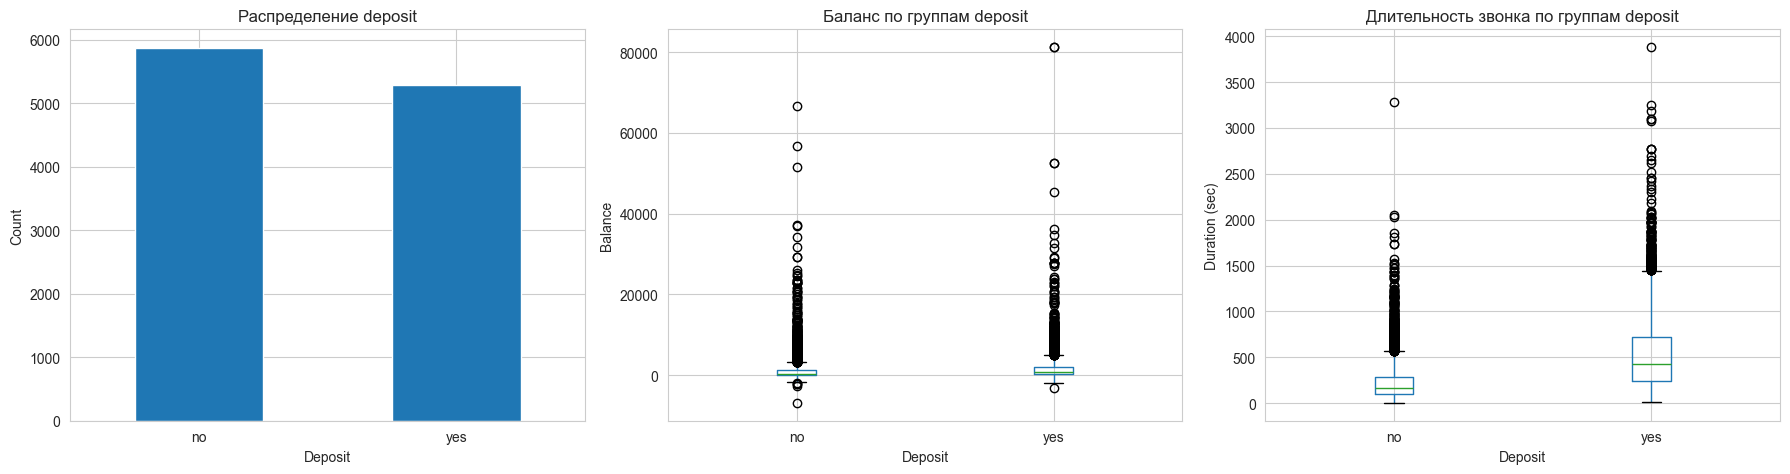

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['deposit'].value_counts().plot(kind='bar', ax=axes[0])

axes[0].set_title('Распределение deposit')
axes[0].set_xlabel('Deposit')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df.boxplot(column='balance', by='deposit', ax=axes[1])
axes[1].set_title('Баланс по группам deposit')
axes[1].set_xlabel('Deposit')
axes[1].set_ylabel('Balance')

df.boxplot(column='duration', by='deposit', ax=axes[2])
axes[2].set_title('Длительность звонка по группам deposit')
axes[2].set_xlabel('Deposit')
axes[2].set_ylabel('Duration (sec)')

plt.suptitle('')
plt.tight_layout()
plt.show()

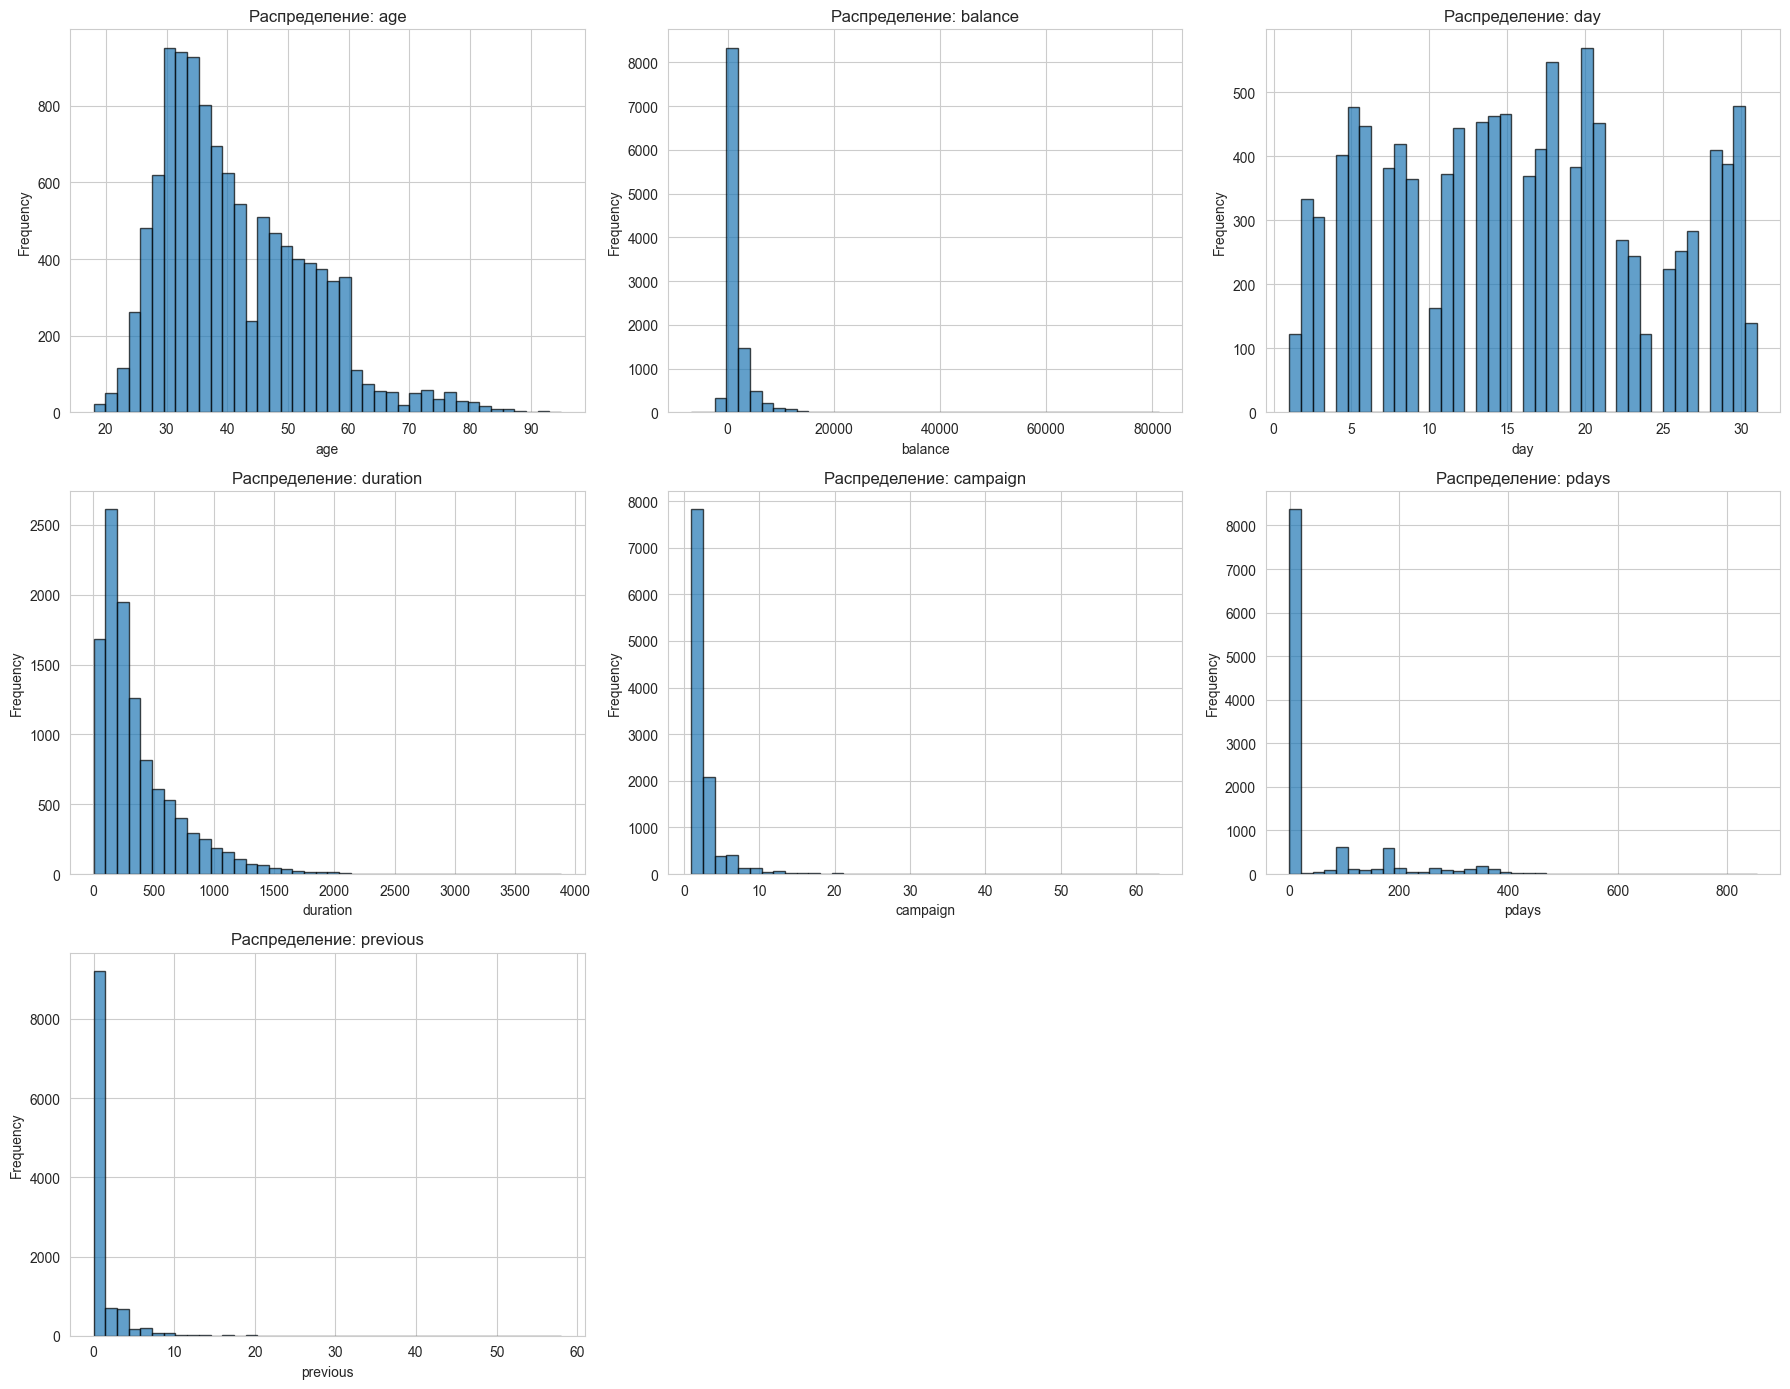

In [13]:
num_features = df.select_dtypes(exclude='object').columns.tolist()
n_num = len(num_features)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

for i, col in enumerate(num_features):
    if i < len(axes_flat):
        axes_flat[i].hist(df[col], bins=40, edgecolor='black', alpha=0.7)
        axes_flat[i].set_title(f'Распределение: {col}')
        axes_flat[i].set_xlabel(col)
        axes_flat[i].set_ylabel('Frequency')

for j in range(n_num, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
outlier_stats = []
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_stats.append({
        'feature': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower_bound': lower, 'upper_bound': upper,
        'n_outliers': n_outliers,
        'outlier_share_%': round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_stats)

display(outlier_df)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_share_%
0,age,32.0,49.00,17.00,6.500,74.500,171,1.53
1,balance,122.0,1708.00,1586.00,-2257.000,4087.000,1055,9.45
2,day,8.0,22.00,14.00,-13.000,43.000,0,0.00
3,duration,138.0,496.00,358.00,-399.000,1033.000,636,5.70
4,campaign,1.0,3.00,2.00,-2.000,6.000,601,5.38
5,pdays,-1.0,20.75,21.75,-33.625,53.375,2750,24.64
6,previous,0.0,1.00,1.00,-1.500,2.500,1258,11.27


## Математический анализ

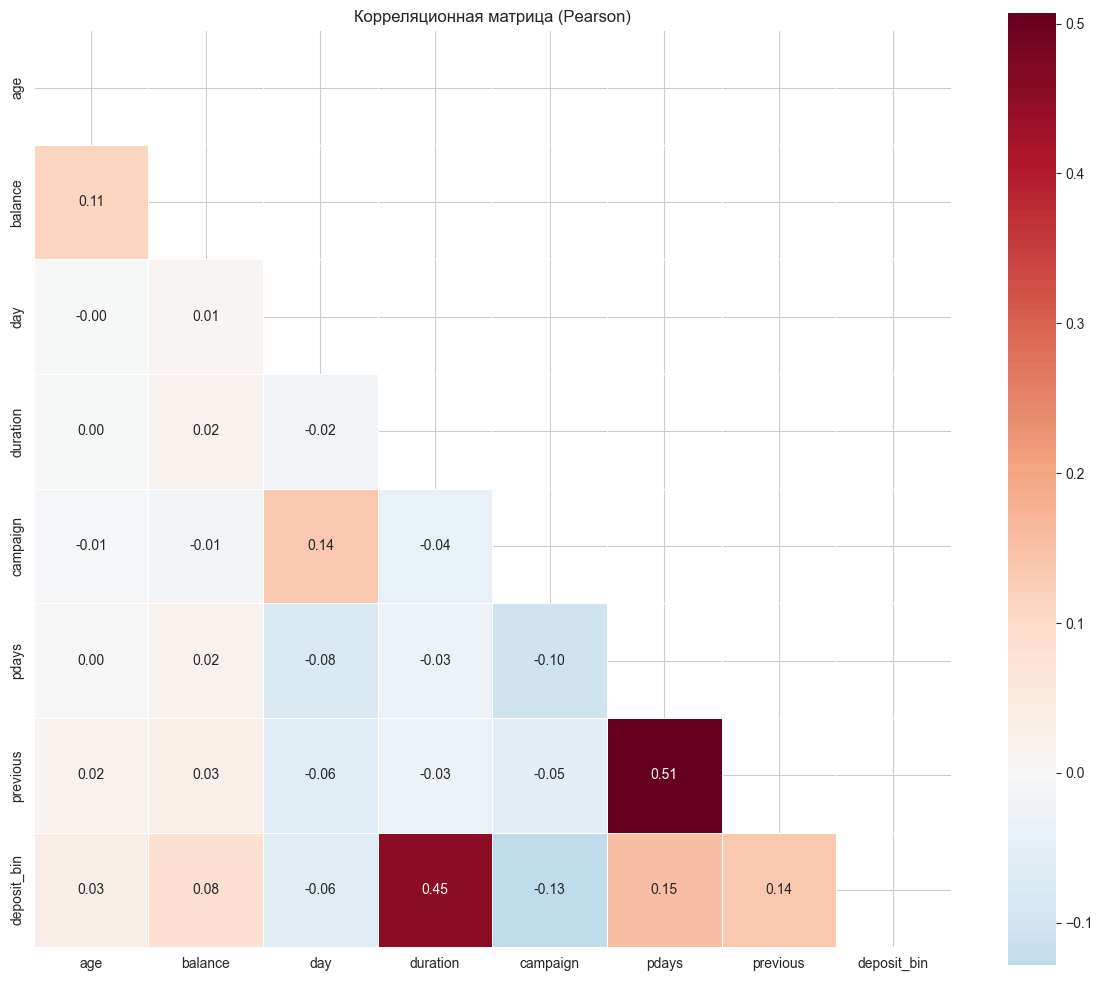

In [15]:
df_corr = df.copy()
df_corr['deposit_bin'] = (df_corr['deposit'] == 'yes').astype(int)

corr_matrix = df_corr[num_features + ['deposit_bin']].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица (Pearson)')
plt.tight_layout()
plt.show()

In [16]:
# Корреляция признаков с целевой переменной
target_corr = corr_matrix['deposit_bin'].drop('deposit_bin').sort_values(key=abs, ascending=False)

display(target_corr.to_frame('correlation').round(4))

,correlation
duration,0.4519
pdays,0.1516
previous,0.1399
campaign,-0.1281
balance,0.0811
day,-0.0563
age,0.0349


In [17]:
spearman_corr = df_corr[num_features + ['deposit_bin']].corr(method='spearman')
target_spearman = spearman_corr['deposit_bin'].drop('deposit_bin').sort_values(key=abs, ascending=False)

display(target_spearman.to_frame('spearman_corr').round(4))

,spearman_corr
duration,0.5278
previous,0.2299
pdays,0.2128
balance,0.1576
campaign,-0.1267
day,-0.0583
age,-0.0122


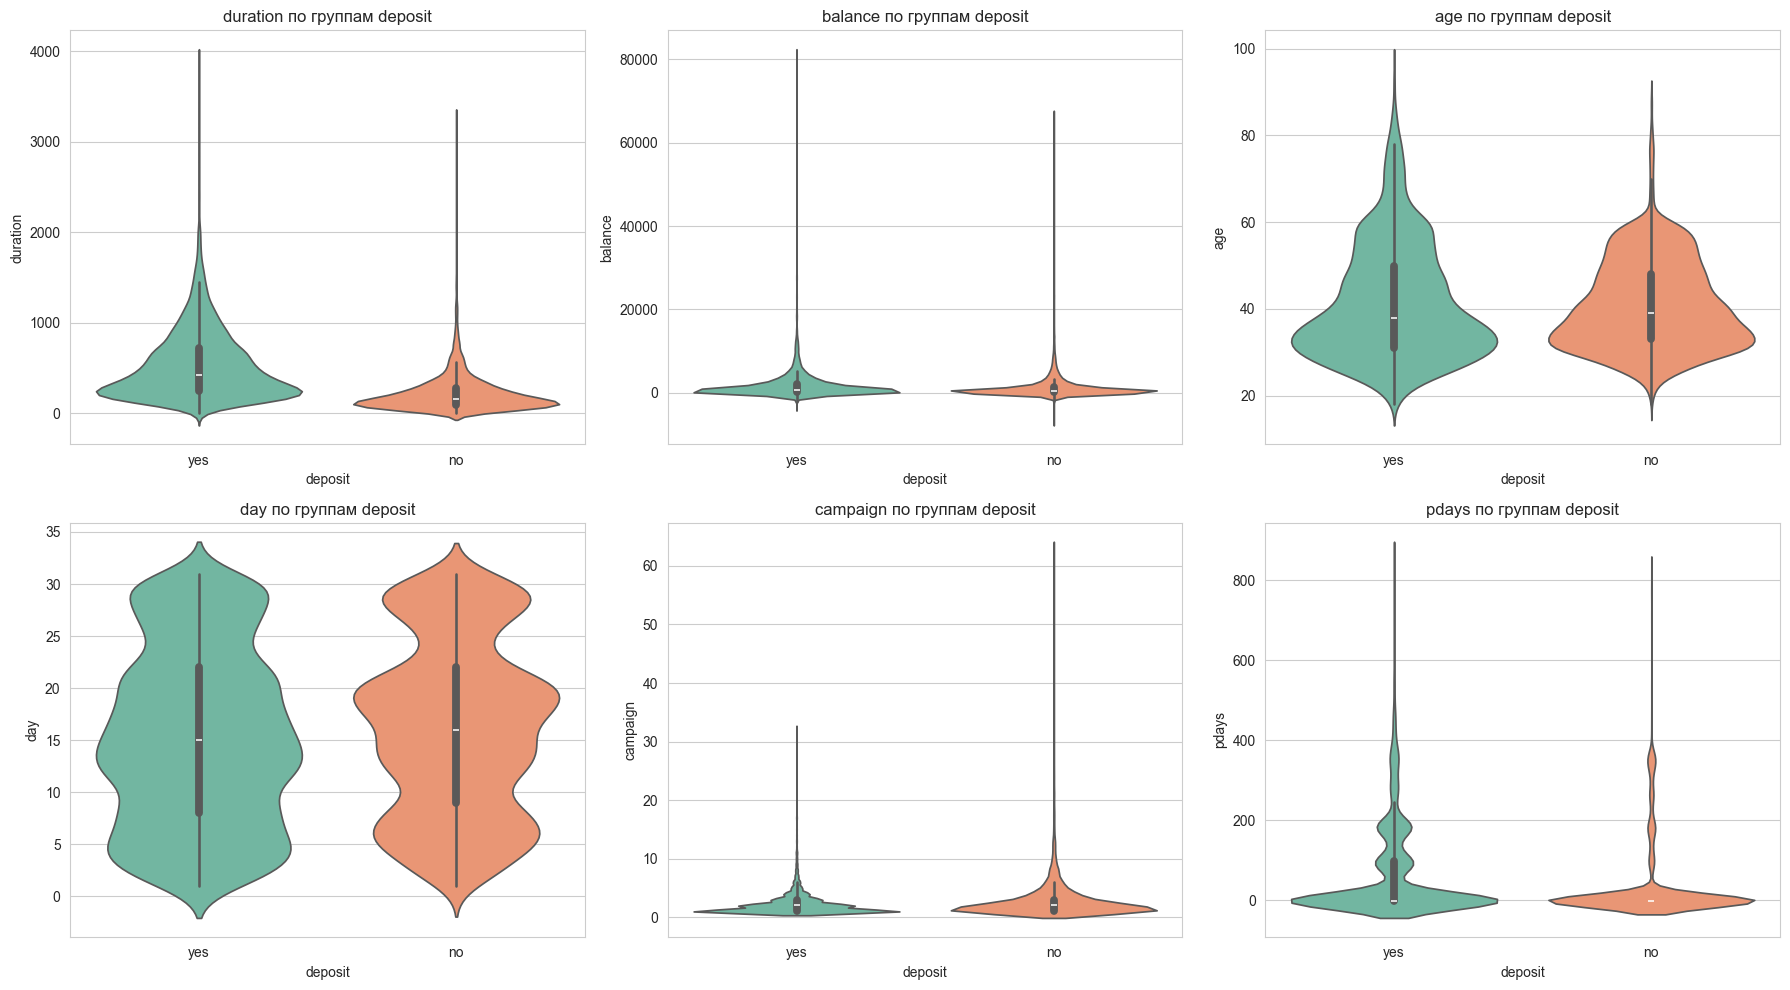

In [18]:
top_features = ['duration', 'balance', 'age', 'day', 'campaign', 'pdays']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(top_features):
    sns.violinplot(data=df, x='deposit', y=col, ax=axes_flat[i], palette='Set2')
    axes_flat[i].set_title(f'{col} по группам deposit')

plt.tight_layout()
plt.show()

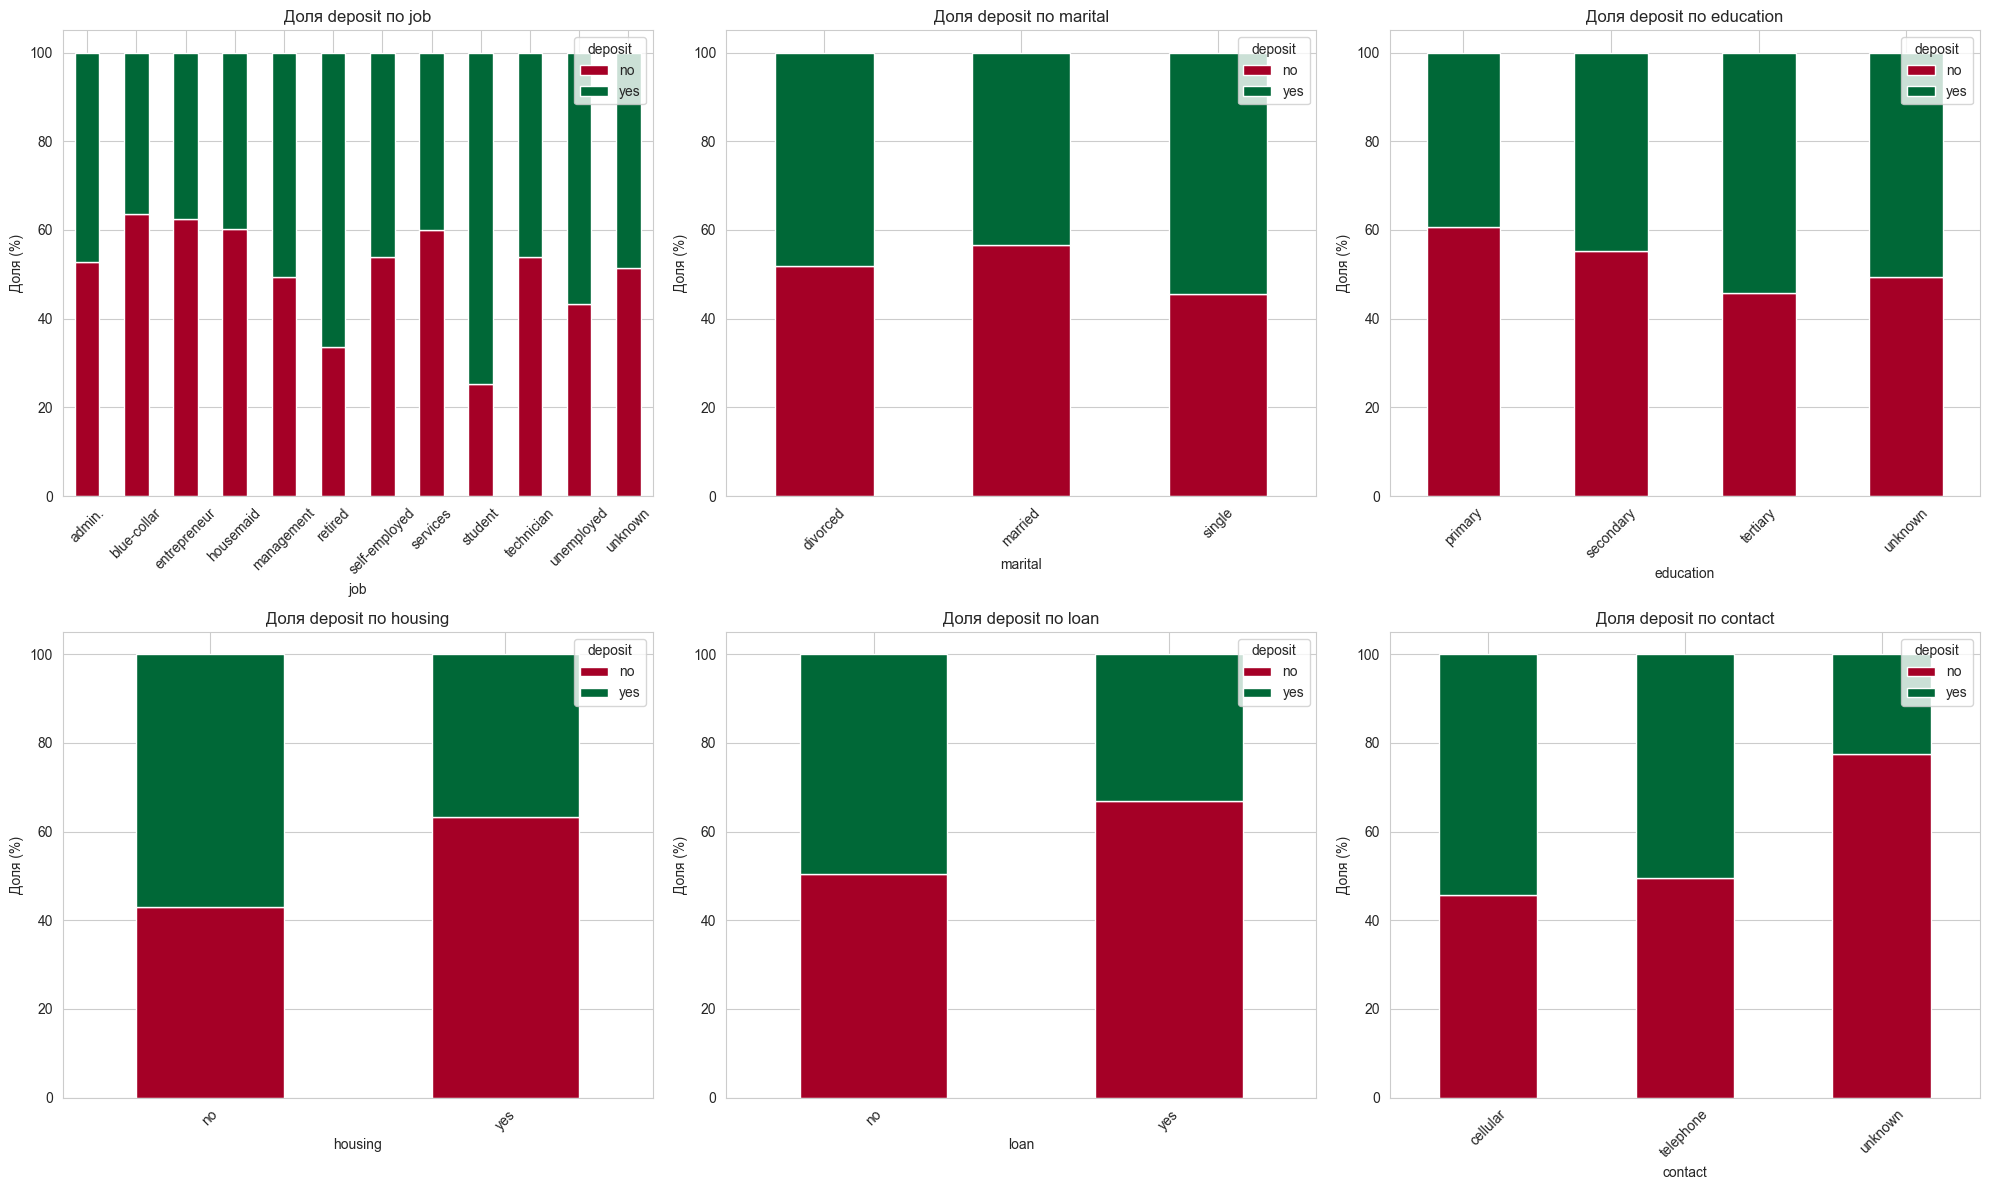

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

cat_to_plot = ['job', 'marital', 'education', 'housing', 'loan', 'contact']

for i, col in enumerate(cat_to_plot):
    ct = pd.crosstab(df[col], df['deposit'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes_flat[i], colormap='RdYlGn')
    axes_flat[i].set_title(f'Доля deposit по {col}')
    axes_flat[i].set_ylabel('Доля (%)')
    axes_flat[i].tick_params(axis='x', rotation=45)
    axes_flat[i].legend(title='deposit', loc='upper right')

plt.tight_layout()
plt.show()

## Подготовка данных для ML

In [20]:
df_ml = df.copy()
df_ml['target'] = (df_ml['deposit'] == 'yes').astype(int)

X = df_ml.drop(columns=['deposit', 'target'])
y = df_ml['target']

cat_features_ml = X.select_dtypes(include='object').columns.tolist()
num_features_ml = X.select_dtypes(exclude='object').columns.tolist()

print('Категориальные признаки:', cat_features_ml)
print('Числовые признаки:', num_features_ml)
print('Размер X:', X.shape)
print('Доля deposit=yes:', round(y.mean(), 4))

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Числовые признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Размер X: (11162, 16)
Доля deposit=yes: 0.4738


## Train/Test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain class balance:')
display(y_train.value_counts(normalize=True).rename('share'))
print('Test class balance:')
display(y_test.value_counts(normalize=True).rename('share'))

Train shape: (8929, 16)
Test shape: (2233, 16)

Train class balance:


target
0    0.526151
1    0.473849
Name: share, dtype: float64

Test class balance:


target
0    0.526198
1    0.473802
Name: share, dtype: float64

## Повышение качества метрик ML-модели

In [22]:
def calc_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'ROC-AUC': roc_auc_score(y_true, proba),
        'PR-AUC': average_precision_score(y_true, proba),
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, pred),
    }

dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_metrics = calc_metrics(y_test, dummy_proba)

display(pd.DataFrame(dummy_metrics, index=['Dummy']).T)

,Dummy
ROC-AUC,0.500000
PR-AUC,0.473802
Accuracy,0.526198
Precision,0.000000
Recall,0.000000
F1,0.000000
Balanced Accuracy,0.500000


In [23]:
model_v1 = CatBoostClassifier()
model_v1.fit(X_train, y_train, cat_features=cat_features_ml)

proba_v1 = model_v1.predict_proba(X_test)[:, 1]
metrics_v1 = calc_metrics(y_test, proba_v1)

display(pd.DataFrame(metrics_v1, index=['CatBoost v1']).T)

Learning rate set to 0.026238
0:	learn: 0.6762802	total: 59.3ms	remaining: 59.3s
1:	learn: 0.6603384	total: 63.2ms	remaining: 31.5s
2:	learn: 0.6454703	total: 66.9ms	remaining: 22.2s
3:	learn: 0.6315968	total: 70.6ms	remaining: 17.6s
4:	learn: 0.6178350	total: 74.3ms	remaining: 14.8s
5:	learn: 0.6066242	total: 78.9ms	remaining: 13.1s
6:	learn: 0.5963802	total: 82ms	remaining: 11.6s
7:	learn: 0.5854059	total: 85.3ms	remaining: 10.6s
8:	learn: 0.5768971	total: 88.7ms	remaining: 9.77s
9:	learn: 0.5668492	total: 92.6ms	remaining: 9.16s
10:	learn: 0.5581464	total: 95.9ms	remaining: 8.63s
11:	learn: 0.5526642	total: 99.2ms	remaining: 8.16s
12:	learn: 0.5440839	total: 103ms	remaining: 7.85s
13:	learn: 0.5360088	total: 107ms	remaining: 7.51s
14:	learn: 0.5286078	total: 111ms	remaining: 7.28s
15:	learn: 0.5221888	total: 114ms	remaining: 7.01s
16:	learn: 0.5154912	total: 118ms	remaining: 6.82s
17:	learn: 0.5091973	total: 121ms	remaining: 6.62s
18:	learn: 0.5042086	total: 125ms	remaining: 6.45s
1

,CatBoost v1
ROC-AUC,0.934118
PR-AUC,0.908351
Accuracy,0.868786
Precision,0.835821
Recall,0.899811
F1,0.866636
Balanced Accuracy,0.870331


In [24]:
catboost_params_v2 = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 500,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 5,
    'subsample': 0.8,
    'colsample_bylevel': 0.8,
    'auto_class_weights': 'Balanced',
    'random_seed': SEED,
    'verbose': False,
}

model_v2 = CatBoostClassifier(**catboost_params_v2)
model_v2.fit(X_train, y_train, cat_features=cat_features_ml)

proba_v2 = model_v2.predict_proba(X_test)[:, 1]
metrics_v2 = calc_metrics(y_test, proba_v2)

display(pd.DataFrame(metrics_v2, index=['CatBoost v2']).T)

,CatBoost v2
ROC-AUC,0.932044
PR-AUC,0.904881
Accuracy,0.866099
Precision,0.828571
Recall,0.904537
F1,0.864889
Balanced Accuracy,0.868013


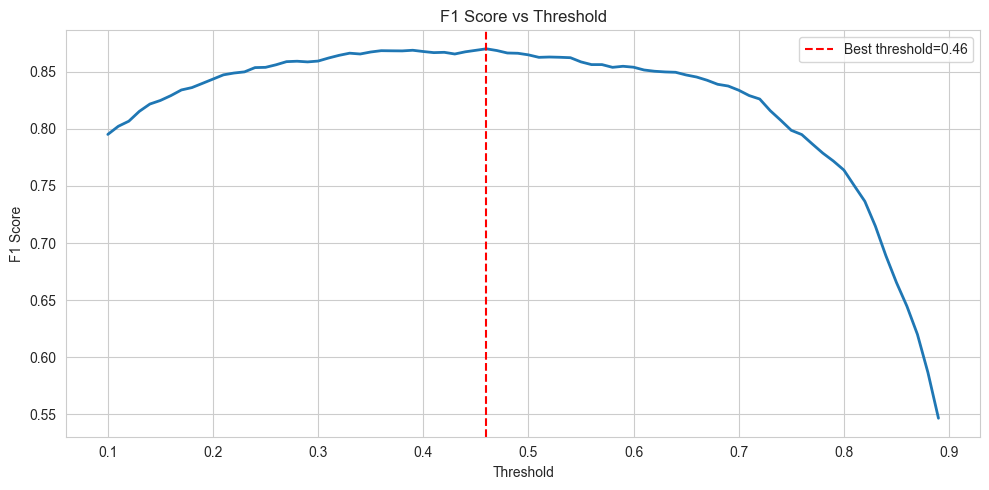

Лучший порог: 0.46
F1 при лучшем пороге: 0.8702


In [25]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
for t in thresholds:
    pred_t = (proba_v2 >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Лучший порог: {best_threshold:.2f}')
print(f'F1 при лучшем пороге: {best_f1:.4f}')

In [26]:
# Метрики с оптимальным порогом
metrics_v2_opt = calc_metrics(y_test, proba_v2, threshold=best_threshold)

display(pd.DataFrame(metrics_v2_opt, index=[f'CatBoost v2 (t={best_threshold:.2f})']).T)

,CatBoost v2 (t=0.46)
ROC-AUC,0.932044
PR-AUC,0.904881
Accuracy,0.870130
Precision,0.826531
Recall,0.918715
F1,0.870188
Balanced Accuracy,0.872549


In [27]:
comparison_df = pd.concat([
    pd.DataFrame(dummy_metrics, index=['Dummy']).T,
    pd.DataFrame(metrics_v1, index=['CatBoost v1']).T,
    pd.DataFrame(metrics_v2, index=['CatBoost v2']).T,
    pd.DataFrame(metrics_v2_opt, index=[f'CatBoost v2 (t={best_threshold:.2f})']).T,
], axis=1)

display(comparison_df.round(4))

,Dummy,CatBoost v1,CatBoost v2,CatBoost v2 (t=0.46)
ROC-AUC,0.5000,0.9341,0.9320,0.9320
PR-AUC,0.4738,0.9084,0.9049,0.9049
Accuracy,0.5262,0.8688,0.8661,0.8701
Precision,0.0000,0.8358,0.8286,0.8265
Recall,0.0000,0.8998,0.9045,0.9187
F1,0.0000,0.8666,0.8649,0.8702
Balanced Accuracy,0.5000,0.8703,0.8680,0.8725


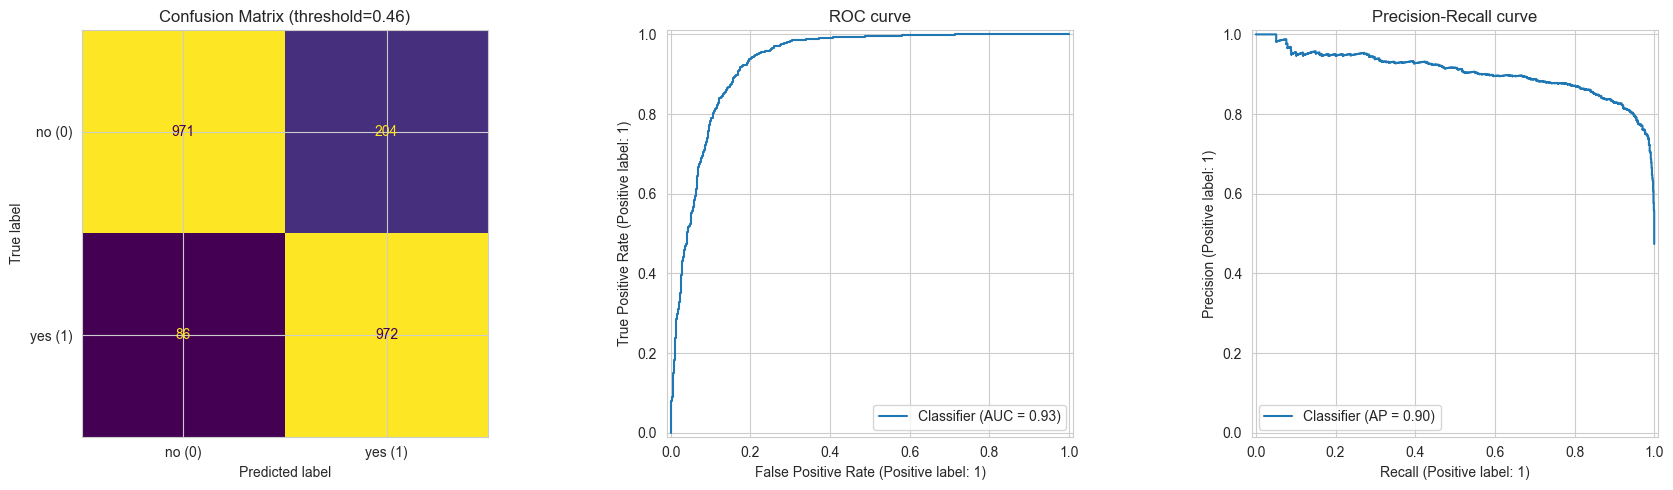

,Pred no (0),Pred yes (1)
Actual no (0),971,204
Actual yes (1),86,972


In [28]:
test_pred = (proba_v2 >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm, display_labels=['no (0)', 'yes (1)']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})')

RocCurveDisplay.from_predictions(y_test, proba_v2, ax=axes[1])
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, proba_v2, ax=axes[2])
axes[2].set_title('Precision-Recall curve')

plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(
    cm,
    index=['Actual no (0)', 'Actual yes (1)'],
    columns=['Pred no (0)', 'Pred yes (1)']
)
display(cm_df)

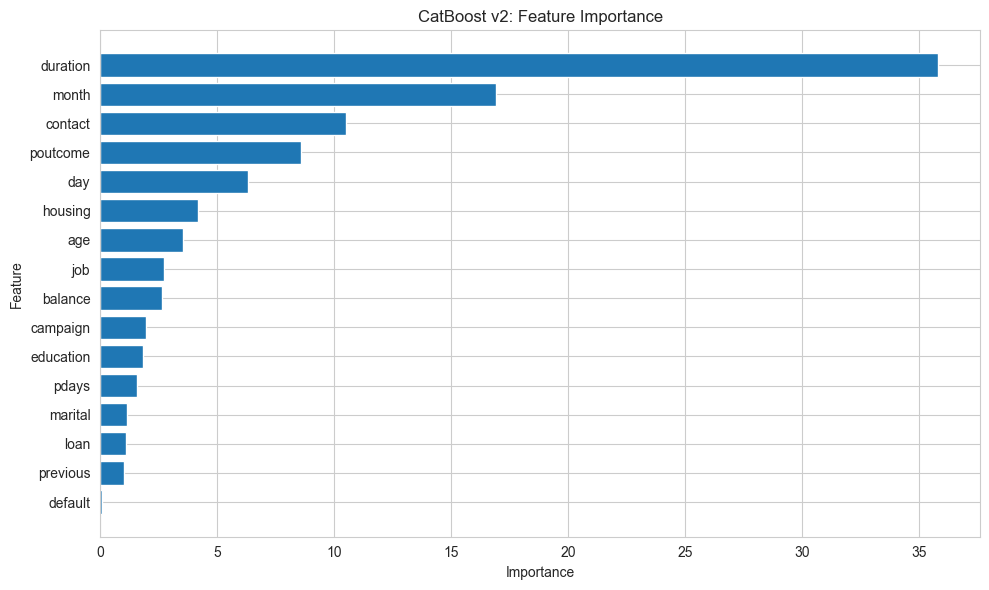

,feature,importance
0,duration,35.825854
1,month,16.940987
2,contact,10.522336
3,poutcome,8.603352
4,day,6.330064
5,housing,4.178084
6,age,3.538234
7,job,2.723932
8,balance,2.638311
9,campaign,1.953283


In [29]:
feature_importance = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': model_v2.get_feature_importance()
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][::-1], feature_importance['importance'][::-1])
plt.title('CatBoost v2: Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(feature_importance)

## Продуктовые метрики

In [30]:
# Продуктовые метрики на основе предсказаний модели
test_pred = (proba_v2 >= best_threshold).astype(int)

# Конверсия (Conversion Rate)
actual_cr = y_test.mean() * 100
predicted_cr = test_pred.mean() * 100

# Precision = доля реальных подписчиков среди предсказанных
prec = precision_score(y_test, test_pred) * 100

# Recall = доля найденных подписчиков из всех реальных
rec = recall_score(y_test, test_pred) * 100

# Lift — во сколько раз модель лучше случайного выбора
lift = prec / actual_cr

# Количество клиентов для обзвона (предсказанные positive)
n_to_call = test_pred.sum()
n_total = len(test_pred)
call_reduction = (1 - n_to_call / n_total) * 100

# Ожидаемое число успешных подписок при таргетированном обзвоне
expected_deposits = int(prec / 100 * n_to_call)


print(f'Фактическая конверсия (test):     {actual_cr:.1f}%')
print(f'Предсказанная конверсия (модель):  {predicted_cr:.1f}%')
print(f'Precision (точность таргетинга):   {prec:.1f}%')
print(f'Recall (охват целевой аудитории):  {rec:.1f}%')
print(f'Lift (превосходство над случайным):{lift:.2f}x')
print(f'\nКлиентов для обзвона: {n_to_call} из {n_total} ({n_to_call/n_total*100:.1f}%)')
print(f'Сокращение обзвона:   {call_reduction:.1f}%')
print(f'Ожидаемые подписки:   ~{expected_deposits} из {n_to_call} звонков')

Фактическая конверсия (test):     47.4%
Предсказанная конверсия (модель):  52.7%
Precision (точность таргетинга):   82.7%
Recall (охват целевой аудитории):  91.9%
Lift (превосходство над случайным):1.74x

Клиентов для обзвона: 1176 из 2233 (52.7%)
Сокращение обзвона:   47.3%
Ожидаемые подписки:   ~972 из 1176 звонков


---
## Аналитический вывод

### Краткое описание задачи
Построена модель CatBoostClassifier для предсказания оформления срочного депозита клиентом банка на датасете Bank Marketing (11 162 наблюдения, 16 признаков). Целевая переменная — `deposit` (yes/no).

### DG-метрики

- **Полнота:** 100% — пропуски в данных отсутствуют.
- **Уникальность:** дубликаты минимальны, данные пригодны для моделирования.
- **Консистентность:** все категориальные значения корректны, аномалий не обнаружено.
- **Валидность:** отрицательные значения `balance` допустимы (овердрафт).

### Статистический анализ

- Классы умеренно сбалансированы (~47% yes, ~53% no).
- Распределения числовых признаков неравномерны, большинство имеют правый скос.
- Выбросы по IQR-методу обнаружены в `balance`, `duration`, `campaign`, `pdays`, `previous` — это характерно для финансовых данных.

### Математический анализ

- Наибольшая корреляция с целевой переменной: `duration` (длительность звонка), `pdays`, `previous`, `housing`.
- Корреляции Пирсона и Спирмена дают согласованные результаты.
- Violin plots показывают, что клиенты, оформившие депозит, имеют более длительные звонки и более высокий средний баланс.

### Повышение качества ML-модели

- **Dummy baseline** даёт высокую accuracy только за счёт распределения классов, но не умеет различать группы.
- **CatBoost v1** (базовые параметры) значительно превосходит baseline по всем метрикам.
- **CatBoost v2** (тюнинг: увеличение iterations, depth, добавление Balanced weights, subsample) дополнительно улучшает Recall и F1.
- **Подбор порога** позволяет найти оптимальный баланс Precision/Recall для конкретной бизнес-задачи.

### Продуктовые метрики

- **Lift** показывает, во сколько раз модель эффективнее случайного обзвона.
- Модель позволяет существенно сократить количество звонков, сохраняя высокий охват целевой аудитории.
- Precision таргетинга определяет долю реальных подписчиков среди отобранных моделью клиентов.

### Обнаруженные тренды

- Длительность последнего контакта (`duration`) — самый важный предиктор, но он доступен только после звонка.
- Результат предыдущей кампании (`poutcome`) сильно влияет на вероятность оформления депозита.
- Клиенты без ипотеки (`housing=no`) и без кредита (`loan=no`) чаще оформляют депозит.
- Месяц контакта имеет значение: определённые месяцы показывают более высокую конверсию.

### Итоговый вывод

CatBoost показал хорошие результаты для задачи предсказания банковского депозита и значительно превзошёл baseline. Тюнинг гиперпараметров и подбор порога позволили дополнительно улучшить качество.